# Обучение и выбор первой модели

В этом notebook создаём признаки, делим данные по времени, сравниваем четыре понятных варианта и выбираем рабочий порог.

## 1. Подготовка данных

In [1]:
import json
import sys
from pathlib import Path

from catboost import CatBoostClassifier
import joblib
from lightgbm import LGBMClassifier, early_stopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.features import build_features

df = pd.read_parquet(ROOT / "data/interim/hotel_bookings_clean.parquet")
df = build_features(df)

In [2]:
month_number = {
    month: number
    for number, month in enumerate(
        [
            "January", "February", "March", "April", "May", "June",
            "July", "August", "September", "October", "November", "December",
        ],
        start=1,
    )
}

df["arrival_date"] = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_number),
    "day": df["arrival_date_day_of_month"],
})
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")

## 2. Временное разделение

In [3]:
train = df[df["booking_date"] < "2016-11-01"].copy()
validation = df[df["booking_date"].between("2016-11-01", "2017-01-31")].copy()
test = df[df["booking_date"].between("2017-02-01", "2017-04-30")].copy()
production = df[df["booking_date"] >= "2017-05-01"].copy()

splits = {
    "train": train,
    "validation": validation,
    "test": test,
    "production": production,
}

for name, data in splits.items():
    splits[name] = data.sort_values("booking_date").reset_index(drop=True)

train, validation, test, production = splits.values()

split_summary = pd.DataFrame([
    {
        "split": name,
        "rows": len(data),
        "date_from": data["booking_date"].min(),
        "date_to": data["booking_date"].max(),
        "cancellation_rate": data["is_canceled"].mean(),
    }
    for name, data in splits.items()
]).set_index("split")

split_summary

,rows,date_from,date_to,cancellation_rate
split,,,,
train,82629,2013-06-24,2016-10-31,0.380109
validation,18065,2016-11-01,2017-01-31,0.392804
test,12117,2017-02-01,2017-04-30,0.325906
production,6579,2017-05-01,2017-08-31,0.269190


In [4]:
assert (
    train["booking_date"].max()
    < validation["booking_date"].min()
    < test["booking_date"].min()
    < production["booking_date"].min()
)

output_dir = ROOT / "data/processed"
output_dir.mkdir(parents=True, exist_ok=True)

for name, data in splits.items():
    data.to_parquet(output_dir / f"{name}.parquet", index=False)

Train содержит прошлые бронирования, validation — следующие три месяца. Февраль–апрель пока не участвуют в выборе модели, а май–август пригодятся позже для monitoring.

Отдельно проверяю только порядок дат между выборками. Ошибка здесь привела бы к leakage и испортила весь эксперимент.

## 3. Признаки и preprocessing

In [5]:
target = "is_canceled"
drop_columns = [target, "arrival_date", "booking_date"]

X_train = train.drop(columns=drop_columns)
y_train = train[target]
X_validation = validation.drop(columns=drop_columns)
y_validation = validation[target]

categorical_columns = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
numeric_columns = X_train.select_dtypes(include="number").columns.tolist()

print("Числовые признаки:", len(numeric_columns))
print("Категориальные признаки:", len(categorical_columns))

Числовые признаки: 20
Категориальные признаки: 12


In [6]:
X_train_encoded = X_train.copy()
X_validation_encoded = X_validation.copy()

for column in categorical_columns:
    X_train_encoded[column] = X_train_encoded[column].astype("object").where(
        X_train_encoded[column].notna(), np.nan
    )
    X_validation_encoded[column] = X_validation_encoded[column].astype("object").where(
        X_validation_encoded[column].notna(), np.nan
    )

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

Для Logistic Regression и LightGBM preprocessing одинаковый: пропуски в числах заполняются медианой, а категории кодируются через One-Hot Encoding. CatBoost получает категории обычными строками и обрабатывает их сам.

## 4. Baseline и модели

In [7]:
def model_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
    }

In [8]:
results = []

dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_validation)[:, 1]
results.append({"model": "Dummy", **model_metrics(y_validation, dummy_proba)})

logistic_regression = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000)),
])
logistic_regression.fit(X_train_encoded, y_train)
logistic_proba = logistic_regression.predict_proba(X_validation_encoded)[:, 1]
results.append({
    "model": "Logistic Regression",
    **model_metrics(y_validation, logistic_proba),
})

In [9]:
lightgbm_preprocessor = clone(preprocessor)
X_train_lgb = lightgbm_preprocessor.fit_transform(X_train_encoded)
X_validation_lgb = lightgbm_preprocessor.transform(X_validation_encoded)

lightgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
lightgbm_model.fit(
    X_train_lgb,
    y_train,
    eval_X=X_validation_lgb,
    eval_y=y_validation,
    eval_metric="auc",
    callbacks=[early_stopping(70, verbose=False)],
)
lightgbm_proba = lightgbm_model.predict_proba(X_validation_lgb)[:, 1]
results.append({
    "model": "LightGBM",
    **model_metrics(y_validation, lightgbm_proba),
})

In [10]:
X_train_catboost = X_train.copy()
X_validation_catboost = X_validation.copy()

for column in categorical_columns:
    X_train_catboost[column] = X_train_catboost[column].astype("string").fillna("Missing")
    X_validation_catboost[column] = (
        X_validation_catboost[column].astype("string").fillna("Missing")
    )

catboost_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)
catboost_model.fit(
    X_train_catboost,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_validation_catboost, y_validation),
    early_stopping_rounds=70,
    use_best_model=True,
)
catboost_proba = catboost_model.predict_proba(X_validation_catboost)[:, 1]
results.append({
    "model": "CatBoost",
    **model_metrics(y_validation, catboost_proba),
})

model_comparison = pd.DataFrame(results).set_index("model")
model_comparison.round(3)

,precision,recall,roc_auc,pr_auc
model,,,,
Dummy,0.000,0.000,0.500,0.393
Logistic Regression,0.719,0.815,0.895,0.864
LightGBM,0.763,0.843,0.925,0.898
CatBoost,0.752,0.846,0.925,0.899


Logistic Regression уже даёт сильный и понятный baseline. Бустинги ранжируют бронирования лучше, а разница между LightGBM и CatBoost небольшая.

Для первой версии логично взять LightGBM: качество конкурентное, а обучение заметно быстрее. CatBoost остаётся следующим кандидатом, если работа с категориями окажется важной на новых данных.

## 5. Небольшой подбор LightGBM

In [11]:
lightgbm_configs = [
    {
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 50,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
    },
    {
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 50,
        "subsample": 0.85,
        "colsample_bytree": 0.70,
    },
    {
        "learning_rate": 0.02,
        "num_leaves": 95,
        "min_child_samples": 20,
        "subsample": 0.70,
        "colsample_bytree": 0.70,
        "reg_lambda": 1.0,
    },
]

tuning_results = []

for config_number, params in enumerate(lightgbm_configs, start=1):
    model = LGBMClassifier(
        n_estimators=1200,
        objective="binary",
        subsample_freq=1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **params,
    )
    model.fit(
        X_train_lgb,
        y_train,
        eval_X=X_validation_lgb,
    eval_y=y_validation,
        eval_metric="auc",
        callbacks=[early_stopping(70, verbose=False)],
    )
    probabilities = model.predict_proba(X_validation_lgb)[:, 1]
    tuning_results.append({
        "config": config_number,
        "best_iteration": model.best_iteration_,
        "roc_auc": roc_auc_score(y_validation, probabilities),
        "pr_auc": average_precision_score(y_validation, probabilities),
    })

tuning_table = pd.DataFrame(tuning_results).sort_values("pr_auc", ascending=False)
tuning_table.round(4)

,config,best_iteration,roc_auc,pr_auc
1,2,248,0.9258,0.8997
0,1,368,0.9257,0.8994
2,3,418,0.9252,0.8986


Все три конфигурации получились близкими. Большой поиск параметров вряд ли даст заметный прирост, поэтому достаточно взять лучшую по PR-AUC и переобучить её с найденным числом деревьев.

In [12]:
best_row = tuning_table.iloc[0]
best_params = lightgbm_configs[int(best_row["config"]) - 1]

final_lightgbm = LGBMClassifier(
    n_estimators=int(best_row["best_iteration"]),
    objective="binary",
    subsample_freq=1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **best_params,
)
final_lightgbm.fit(X_train_lgb, y_train)
validation_proba = final_lightgbm.predict_proba(X_validation_lgb)[:, 1]

## 6. Рабочий порог

In [13]:
precision, recall, thresholds = precision_recall_curve(y_validation, validation_proba)
threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

best_threshold = (
    threshold_table[threshold_table["precision"] >= 0.70]
    .sort_values(["recall", "precision"], ascending=False)
    .iloc[0]
)
threshold = float(best_threshold["threshold"])

pd.Series(model_metrics(y_validation, validation_proba, threshold)).round(3)

precision    0.700
recall       0.907
roc_auc      0.926
pr_auc       0.900
dtype: float64

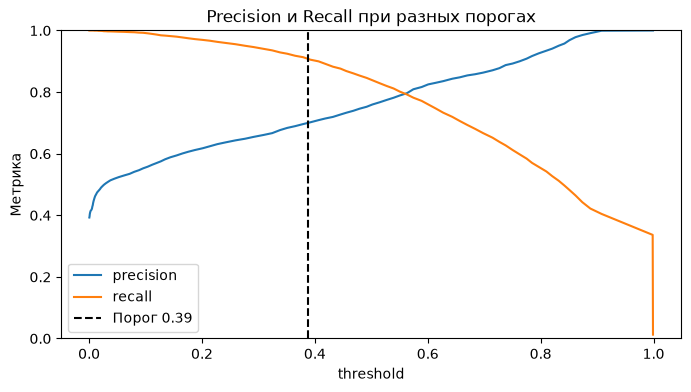

In [14]:
threshold_view = threshold_table.iloc[:: max(1, len(threshold_table) // 100)]
threshold_view.plot(
    x="threshold",
    y=["precision", "recall"],
    figsize=(8, 4),
)
plt.axvline(threshold, color="black", linestyle="--", label=f"Порог {threshold:.2f}")
plt.title("Precision и Recall при разных порогах")
plt.ylabel("Метрика")
plt.ylim(0, 1)
plt.legend()
plt.show()

Бизнес-правило простое: среди порогов с `Precision >= 0.70` нужен тот, где Recall максимальный. После этого модель и порог считаются зафиксированными — под следующий период их уже не подгоняем.

## 7. Сохранение LightGBM v1

In [15]:
model_dir = ROOT / "models"
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(lightgbm_preprocessor, model_dir / "preprocessor.joblib")
joblib.dump(final_lightgbm, model_dir / "lightgbm_v1.joblib")

metadata = {
    "model": "LightGBM",
    "version": "v1",
    "threshold": threshold,
    "categorical_cols": categorical_columns,
    "drop_cols": drop_columns,
}

with (model_dir / "lightgbm_v1_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

## Итог

Первая версия модели — LightGBM с отдельным preprocessing и порогом, выбранным на validation. Следующий шаг — посмотреть, как эта связка перенесётся на бронирования февраля–апреля, которых модель раньше не видела.